# 16A — AIA + SHARP Fusion Training Protocol

**Purpose.** This notebook prepares the first true multimodal AIA + SHARP fusion experiment.

It is a **local CPU-only protocol/design notebook**.  
It does **not** train the AIA image model and does **not** load image `.npz` files.

## Why 16A exists

Before starting the GPU VM again, this notebook locks down:

1. the AIA-only baseline evidence;
2. the SHARP-only baseline evidence;
3. the leakage/robustness audit status;
4. the fusion folds and sample counts;
5. the recommended fusion architecture;
6. the exact inputs required for the GPU training notebook;
7. the scientific wording for the paper/research log.

## Scientific framing

This experiment remains **Solar Cycle 24 only**.  
The correct claim is **within-cycle chronological/regime robustness**, not Cycle 24 → Cycle 25 generalisation.

## Modality rule

- **AIA branch:** image morphology / coronal EUV emission context.
- **SHARP branch:** magnetic-field/evolution features.
- **GOES:** label-lineage only for now through `label_48h_final`; no GOES/XRS input features are used in this fusion plan.

## Evaluation rule

All thresholds must be selected on validation TSS and then applied unchanged to the held-out test year.


In [1]:
from pathlib import Path
import json
from datetime import datetime
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / ".git").exists() and (p / "training").exists():
            return p
    for p in candidates:
        if (p / "training").exists() and (p / "results").exists():
            return p
    raise RuntimeError("Could not find project root. Run from inside the solar-flare-aia-training repo.")

ROOT = find_project_root()
TRAINING_DIR = ROOT / "training"
FUSION_DIR = TRAINING_DIR / "fusion_manifests"
METRICS_DIR = ROOT / "results" / "metrics"
FIG_DIR = ROOT / "results" / "figures"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("Generated:", datetime.now().isoformat(timespec="seconds"))


ROOT: /Users/mac/Projects/solar-flare-aia-training
Generated: 2026-08-03T18:54:03


## 1. Source-file inventory

In [2]:
SOURCE_FILES = {
    "fusion_alignment_manifest": FUSION_DIR / "aia_sharp_goes_fusion_alignment_manifest_2010_2016.csv",
    "fusion_fold_assignments": FUSION_DIR / "aia_sharp_goes_fusion_fold_assignments_2013_2015.csv",
    "fusion_fold_summary": METRICS_DIR / "aia_sharp_goes_fusion_fold_summary.csv",
    "aia_fold2015_image_baseline_comparison": METRICS_DIR / "aia_fold2015_image_baseline_comparison.csv",
    "aia_resnet18_multifold_summary": METRICS_DIR / "aia_resnet18_physics_safe_multifold_fullnatural_summary.csv",
    "aia_resnet18_hp_summary": METRICS_DIR / "aia_resnet18_hp_sensitivity_multifold_config_summary.csv",
    "aia_cycle_regime_summary": METRICS_DIR / "aia_resnet18_cycle_phase_regime_diagnostics_config_fold_summary.csv",
    "sharp_baseline_all_results": METRICS_DIR / "sharp_temporal_baseline_all_results.csv",
    "sharp_baseline_config_summary": METRICS_DIR / "sharp_temporal_baseline_config_summary.csv",
    "sharp_selection_summary": METRICS_DIR / "sharp_temporal_baseline_selection_summary.json",
    "sharp_leakage_audit_report": METRICS_DIR / "sharp_temporal_leakage_audit_report.md",
    "sharp_leakage_ablation": METRICS_DIR / "sharp_temporal_leakage_audit_history_count_ablation.csv",
}

inventory = pd.DataFrame([
    {
        "name": name,
        "path": str(path.relative_to(ROOT)),
        "exists": path.exists(),
        "size_mb": path.stat().st_size / (1024**2) if path.exists() else np.nan,
    }
    for name, path in SOURCE_FILES.items()
])

inventory_path = METRICS_DIR / "aia_sharp_fusion_protocol_source_inventory.csv"
inventory.to_csv(inventory_path, index=False)

print("Saved:", inventory_path)
display(inventory)


Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_sharp_fusion_protocol_source_inventory.csv


,name,path,exists,size_mb
0,fusion_alignment_manifest,training/fusion_manifests/aia_sharp_goes_fusio...,True,40.353666
1,fusion_fold_assignments,training/fusion_manifests/aia_sharp_goes_fusio...,True,93.569663
2,fusion_fold_summary,results/metrics/aia_sharp_goes_fusion_fold_sum...,True,0.000783
3,aia_fold2015_image_baseline_comparison,results/metrics/aia_fold2015_image_baseline_co...,True,0.001357
4,aia_resnet18_multifold_summary,results/metrics/aia_resnet18_physics_safe_mult...,True,0.000878
5,aia_resnet18_hp_summary,results/metrics/aia_resnet18_hp_sensitivity_mu...,True,0.001256
6,aia_cycle_regime_summary,results/metrics/aia_resnet18_cycle_phase_regim...,True,0.002542
7,sharp_baseline_all_results,results/metrics/sharp_temporal_baseline_all_re...,True,0.021285
8,sharp_baseline_config_summary,results/metrics/sharp_temporal_baseline_config...,True,0.003617
9,sharp_selection_summary,results/metrics/sharp_temporal_baseline_select...,True,0.000717


## 2. Load AIA-only and SHARP-only evidence

In [3]:
def read_csv_if_exists(path):
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

aia_fold2015 = read_csv_if_exists(SOURCE_FILES["aia_fold2015_image_baseline_comparison"])
aia_multifold = read_csv_if_exists(SOURCE_FILES["aia_resnet18_multifold_summary"])
aia_hp = read_csv_if_exists(SOURCE_FILES["aia_resnet18_hp_summary"])
aia_regime = read_csv_if_exists(SOURCE_FILES["aia_cycle_regime_summary"])

sharp_all = read_csv_if_exists(SOURCE_FILES["sharp_baseline_all_results"])
sharp_summary = read_csv_if_exists(SOURCE_FILES["sharp_baseline_config_summary"])
sharp_ablation = read_csv_if_exists(SOURCE_FILES["sharp_leakage_ablation"])
fusion_fold_summary = read_csv_if_exists(SOURCE_FILES["fusion_fold_summary"])

sharp_selection = {}
if SOURCE_FILES["sharp_selection_summary"].exists():
    with open(SOURCE_FILES["sharp_selection_summary"], "r") as f:
        sharp_selection = json.load(f)

print("AIA fold2015:", aia_fold2015.shape)
print("AIA multifold:", aia_multifold.shape)
print("AIA HP:", aia_hp.shape)
print("AIA regime:", aia_regime.shape)
print("SHARP all:", sharp_all.shape)
print("SHARP summary:", sharp_summary.shape)
print("SHARP selection:", sharp_selection.get("model_name"), sharp_selection.get("feature_view"))

display(fusion_fold_summary)
display(sharp_summary.head())


AIA fold2015: (4, 27)
AIA multifold: (3, 24)
AIA HP: (4, 30)
AIA regime: (12, 24)
SHARP all: (30, 50)
SHARP summary: (10, 18)
SHARP selection: random_forest_balanced temporal_24h_available_preferred


,fusion_fold_id,fusion_split,rows,positives,sharp_matched,mean_year,negatives,positive_rate,sharp_match_rate
0,fusion_test_2013,test,13066,492,13066,2013.000000,12574,0.037655,1.0
1,fusion_test_2013,train,14448,433,14448,2010.771179,14015,0.029970,1.0
2,fusion_test_2013,val,10815,305,10815,2012.000000,10510,0.028202,1.0
3,fusion_test_2014,test,11627,629,11627,2014.000000,10998,0.054098,1.0
4,fusion_test_2014,train,25263,738,25263,2011.297233,24525,0.029213,1.0
5,fusion_test_2014,val,13066,492,13066,2013.000000,12574,0.037655,1.0
6,fusion_test_2015,test,11236,531,11236,2015.000000,10705,0.047259,1.0
7,fusion_test_2015,train,38329,1230,38329,2011.877691,37099,0.032091,1.0
8,fusion_test_2015,val,11627,629,11627,2014.000000,10998,0.054098,1.0


,feature_view,model_name,n_folds,mean_val_tss,std_val_tss,mean_test_tss,std_test_tss,mean_test_hss,std_test_hss,mean_test_roc_auc,std_test_roc_auc,mean_test_pr_auc,std_test_pr_auc,mean_test_precision,mean_test_recall,mean_test_specificity,mean_test_f1,mean_diagnostic_minus_official_tss
0,temporal_24h_available_preferred,random_forest_balanced,3,0.733702,0.114183,0.640181,0.190157,0.299614,0.134054,0.917001,0.062029,0.399801,0.179299,0.225173,0.760258,0.879922,0.342832,0.090177
1,temporal_12h_available_preferred,random_forest_balanced,3,0.660202,0.110855,0.708751,0.077932,0.249605,0.041793,0.932211,0.029014,0.453709,0.096661,0.185312,0.896342,0.812409,0.305512,0.038621
2,snapshot_available_preferred,random_forest_balanced,3,0.658896,0.070833,0.688684,0.085122,0.291590,0.011091,0.921716,0.027388,0.434701,0.082468,0.216964,0.833580,0.855104,0.343378,0.029172
3,snapshot_available_preferred,logistic_regression_balanced,3,0.642595,0.066605,0.679788,0.130640,0.254288,0.132772,0.913007,0.053684,0.483198,0.129867,0.194159,0.882739,0.797049,0.310887,0.019767
4,temporal_6h_available_preferred,random_forest_balanced,3,0.630478,0.077788,0.697407,0.068557,0.232351,0.017371,0.926733,0.031296,0.437839,0.073372,0.174218,0.901754,0.795653,0.291089,0.041561


## 3. Build branch comparison table

In [4]:
comparison_rows = []

def metric_mean(df, *names):
    for name in names:
        if name in df.columns:
            return df[name].mean()
    return np.nan

def metric_std(df, *names):
    for name in names:
        if name in df.columns:
            return df[name].std()
    return np.nan


# AIA-only ResNet18 full-natural multifold baseline.
if not aia_multifold.empty:
    # Expected columns: fold_id, test_tss, test_roc_auc, test_pr_auc, etc.
    row = {
        "branch": "AIA_only",
        "candidate_name": "ResNet18 physics-safe full-natural multifold",
        "status": "completed",
        "solar_cycle_scope": "Solar_Cycle_24_only",
        "goes_usage": "label_lineage_only",
        "n_folds": aia_multifold["fold_id"].nunique() if "fold_id" in aia_multifold.columns else len(aia_multifold),
        "mean_test_tss": metric_mean(aia_multifold, "test_tss", "tss"),
        "std_test_tss": metric_std(aia_multifold, "test_tss", "tss"),
        "mean_test_hss": metric_mean(aia_multifold, "test_hss", "hss"),
        "mean_test_roc_auc": metric_mean(aia_multifold, "test_roc_auc", "roc_auc"),
        "mean_test_pr_auc": metric_mean(aia_multifold, "test_pr_auc", "pr_auc"),
        "coverage_note": "AIA full-natural fold-specific image baseline.",
        "paper_role": "image_branch_baseline",
    }
    comparison_rows.append(row)

# AIA hyperparameter-selected result if available.
if not aia_hp.empty and {"config_name", "test_tss_mean"}.issubset(aia_hp.columns):
    s = aia_hp.sort_values("val_tss_mean", ascending=False).iloc[0]
    comparison_rows.append({
        "branch": "AIA_only",
        "candidate_name": f"ResNet18 HP selected: {s['config_name']}",
        "status": "completed",
        "solar_cycle_scope": "Solar_Cycle_24_only",
        "goes_usage": "label_lineage_only",
        "n_folds": s.get("n", np.nan),
        "mean_test_tss": s.get("test_tss_mean", np.nan),
        "std_test_tss": s.get("test_tss_std", np.nan),
        "mean_test_hss": s.get("test_hss_mean", np.nan),
        "mean_test_roc_auc": s.get("test_roc_auc_mean", np.nan),
        "mean_test_pr_auc": s.get("test_pr_auc_mean", np.nan),
        "coverage_note": "AIA-only hyperparameter sensitivity; selected by validation TSS.",
        "paper_role": "image_branch_sensitivity",
    })

# SHARP selected branch.
if not sharp_summary.empty:
    if "mean_val_tss" in sharp_summary.columns:
        s = sharp_summary.sort_values(["mean_val_tss", "mean_test_tss"], ascending=False).iloc[0]
    else:
        s = sharp_summary.iloc[0]
    comparison_rows.append({
        "branch": "SHARP_only",
        "candidate_name": f"{s['model_name']} + {s['feature_view']}",
        "status": "completed_audited",
        "solar_cycle_scope": "Solar_Cycle_24_only",
        "goes_usage": "label_lineage_only_no_goes_input_features",
        "n_folds": s.get("n_folds", np.nan),
        "mean_test_tss": s.get("mean_test_tss", np.nan),
        "std_test_tss": s.get("std_test_tss", np.nan),
        "mean_test_hss": s.get("mean_test_hss", np.nan),
        "mean_test_roc_auc": s.get("mean_test_roc_auc", np.nan),
        "mean_test_pr_auc": s.get("mean_test_pr_auc", np.nan),
        "coverage_note": "24h temporal view is strong but coverage-limited; audit found no obvious leakage shortcut.",
        "paper_role": "magnetic_branch_baseline",
    })

# Conservative SHARP ablation without history_count.
if not sharp_ablation.empty:
    abl = (
        sharp_ablation.groupby("ablation", as_index=False)
        .agg(
            mean_test_tss=("test_tss", "mean"),
            std_test_tss=("test_tss", "std"),
            mean_test_hss=("test_hss", "mean"),
            mean_test_roc_auc=("test_roc_auc", "mean"),
            mean_test_pr_auc=("test_pr_auc", "mean"),
            n_folds=("fold_id", "nunique"),
        )
    )
    no_count = abl[abl["ablation"].eq("without_history_count")]
    if len(no_count):
        s = no_count.iloc[0]
        comparison_rows.append({
            "branch": "SHARP_only_conservative",
            "candidate_name": "Random Forest 24h temporal without history_count",
            "status": "completed_audited_ablation",
            "solar_cycle_scope": "Solar_Cycle_24_only",
            "goes_usage": "label_lineage_only_no_goes_input_features",
            "n_folds": s.get("n_folds", np.nan),
            "mean_test_tss": s.get("mean_test_tss", np.nan),
            "std_test_tss": s.get("std_test_tss", np.nan),
            "mean_test_hss": s.get("mean_test_hss", np.nan),
            "mean_test_roc_auc": s.get("mean_test_roc_auc", np.nan),
            "mean_test_pr_auc": s.get("mean_test_pr_auc", np.nan),
            "coverage_note": "Conservative ablation confirms performance is not driven by history_count.",
            "paper_role": "conservative_magnetic_branch_reference",
        })

branch_comparison = pd.DataFrame(comparison_rows)
branch_comparison_path = METRICS_DIR / "aia_sharp_fusion_protocol_branch_comparison.csv"
branch_comparison.to_csv(branch_comparison_path, index=False)

print("Saved:", branch_comparison_path)
display(branch_comparison)


Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_sharp_fusion_protocol_branch_comparison.csv


,branch,candidate_name,status,solar_cycle_scope,goes_usage,n_folds,mean_test_tss,std_test_tss,mean_test_hss,mean_test_roc_auc,mean_test_pr_auc,coverage_note,paper_role
0,AIA_only,ResNet18 physics-safe full-natural multifold,completed,Solar_Cycle_24_only,label_lineage_only,3.0,0.233900,0.222717,0.042933,0.634800,0.069167,AIA full-natural fold-specific image baseline.,image_branch_baseline
1,AIA_only,ResNet18 HP selected: higher_dropout,completed,Solar_Cycle_24_only,label_lineage_only,NaN,0.181900,0.140900,0.039800,0.631100,0.080200,AIA-only hyperparameter sensitivity; selected ...,image_branch_sensitivity
2,SHARP_only,random_forest_balanced + temporal_24h_availabl...,completed_audited,Solar_Cycle_24_only,label_lineage_only_no_goes_input_features,3.0,0.640181,0.190157,0.299614,0.917001,0.399801,24h temporal view is strong but coverage-limit...,magnetic_branch_baseline
3,SHARP_only_conservative,Random Forest 24h temporal without history_count,completed_audited_ablation,Solar_Cycle_24_only,label_lineage_only_no_goes_input_features,3.0,0.633028,0.205241,0.308124,0.915921,0.394170,Conservative ablation confirms performance is ...,conservative_magnetic_branch_reference


## 4. Fusion candidate decision

In [5]:
# Decision rule:
# - use SHARP 24h temporal RF result as a reference baseline;
# - for neural fusion, start with SHARP feature vector without history_count unless we explicitly include it in sensitivity;
# - AIA branch begins from ResNet18 physics-safe image backbone.

candidate = {
    "fusion_experiment_name": "aia_resnet18_sharp24h_intermediate_fusion_cycle24",
    "solar_cycle_scope": "Solar_Cycle_24_only_2010_2015",
    "claim_scope": "within_cycle_chronological_regime_robustness",
    "aia_branch": {
        "input": "6-channel AIA EUV NPZ image tensor",
        "backbone": "ResNet18 adapted to six channels",
        "preprocessing": "physics-safe train-only robust channel scaling; no random flips/rotations/crops",
        "embedding": "global pooled image embedding before classifier head",
    },
    "sharp_branch": {
        "input": "24h leakage-safe SHARP temporal aggregate vector",
        "preferred_features_available": "15 preferred SHARP features; TOTUSJH audited missing",
        "history_count_policy": "exclude from primary fusion input; include only as sensitivity after audit",
        "normalisation": "train-only imputation/scaling fitted per fold",
    },
    "goes_branch": {
        "current_status": "label-lineage only",
        "input_features": "not used in first AIA+SHARP fusion",
        "future_work": "extract past-only GOES/XRS history features in separate notebook",
    },
    "folds": {
        "test_2013": {"train_years": [2010, 2011], "val_years": [2012], "test_years": [2013]},
        "test_2014": {"train_years": [2010, 2011, 2012], "val_years": [2013], "test_years": [2014]},
        "test_2015": {"train_years": [2010, 2011, 2012, 2013], "val_years": [2014], "test_years": [2015]},
    },
    "threshold_rule": "select threshold by validation TSS only; apply unchanged to test",
    "primary_metrics": ["TSS", "HSS", "ROC-AUC", "PR-AUC", "Precision", "Recall", "Specificity", "F1", "Brier"],
}

candidate_path = METRICS_DIR / "aia_sharp_fusion_protocol_candidate_selection.json"
candidate_path.write_text(json.dumps(candidate, indent=2), encoding="utf-8")

candidate_table = pd.DataFrame([
    {"item": "fusion_experiment_name", "decision": candidate["fusion_experiment_name"]},
    {"item": "solar_cycle_scope", "decision": candidate["solar_cycle_scope"]},
    {"item": "claim_scope", "decision": candidate["claim_scope"]},
    {"item": "aia_branch", "decision": "six-channel ResNet18 physics-safe image embedding"},
    {"item": "sharp_branch", "decision": "24h temporal aggregate vector; primary fusion excludes history_count"},
    {"item": "goes_usage", "decision": "label-lineage only; no GOES/XRS input features"},
    {"item": "threshold_rule", "decision": candidate["threshold_rule"]},
])
candidate_table_path = METRICS_DIR / "aia_sharp_fusion_protocol_candidate_selection.csv"
candidate_table.to_csv(candidate_table_path, index=False)

print("Saved:", candidate_path)
print("Saved:", candidate_table_path)
display(candidate_table)


Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_sharp_fusion_protocol_candidate_selection.json
Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_sharp_fusion_protocol_candidate_selection.csv


,item,decision
0,fusion_experiment_name,aia_resnet18_sharp24h_intermediate_fusion_cycle24
1,solar_cycle_scope,Solar_Cycle_24_only_2010_2015
2,claim_scope,within_cycle_chronological_regime_robustness
3,aia_branch,six-channel ResNet18 physics-safe image embedding
4,sharp_branch,24h temporal aggregate vector; primary fusion ...
5,goes_usage,label-lineage only; no GOES/XRS input features
6,threshold_rule,select threshold by validation TSS only; apply...


## 5. Fusion fold and coverage readiness

In [6]:
# Load fusion fold assignments only if needed for counts. It is large but manageable locally.
fold_assignments_path = SOURCE_FILES["fusion_fold_assignments"]

if fold_assignments_path.exists():
    fold_assign_cols = ["fusion_fold_id", "fusion_split", "sample_id", "year", "official_label_48h_final", "gcp_path"]
    # Some pandas versions do not support missing usecols gracefully; read header first.
    header_cols = list(pd.read_csv(fold_assignments_path, nrows=0).columns)
    usecols = [c for c in fold_assign_cols if c in header_cols]
    fold_assign = pd.read_csv(fold_assignments_path, usecols=usecols)

    readiness = (
        fold_assign.groupby(["fusion_fold_id", "fusion_split"], as_index=False)
        .agg(
            rows=("sample_id", "count"),
            positives=("official_label_48h_final", "sum"),
            years=("year", lambda x: ",".join(map(str, sorted(pd.Series(x).dropna().astype(int).unique())))),
            aia_paths_available=("gcp_path", lambda x: int(pd.Series(x).notna().sum())) if "gcp_path" in fold_assign.columns else ("sample_id", "count"),
        )
    )
    readiness["negatives"] = readiness["rows"] - readiness["positives"]
    readiness["positive_rate"] = readiness["positives"] / readiness["rows"]
    readiness["aia_path_rate"] = readiness["aia_paths_available"] / readiness["rows"]
else:
    readiness = fusion_fold_summary.copy()

readiness_path = METRICS_DIR / "aia_sharp_fusion_protocol_fold_readiness.csv"
readiness.to_csv(readiness_path, index=False)

print("Saved:", readiness_path)
display(readiness)


Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_sharp_fusion_protocol_fold_readiness.csv


,fusion_fold_id,fusion_split,rows,positives,years,aia_paths_available,negatives,positive_rate,aia_path_rate
0,fusion_test_2013,test,13066,492,2013,13066,12574,0.037655,1.0
1,fusion_test_2013,train,14448,433,"2010,2011",14448,14015,0.029970,1.0
2,fusion_test_2013,val,10815,305,2012,10815,10510,0.028202,1.0
3,fusion_test_2014,test,11627,629,2014,11627,10998,0.054098,1.0
4,fusion_test_2014,train,25263,738,"2010,2011,2012",25263,24525,0.029213,1.0
5,fusion_test_2014,val,13066,492,2013,13066,12574,0.037655,1.0
6,fusion_test_2015,test,11236,531,2015,11236,10705,0.047259,1.0
7,fusion_test_2015,train,38329,1230,"2010,2011,2012,2013",38329,37099,0.032091,1.0
8,fusion_test_2015,val,11627,629,2014,11627,10998,0.054098,1.0


## 6. Visual branch comparison

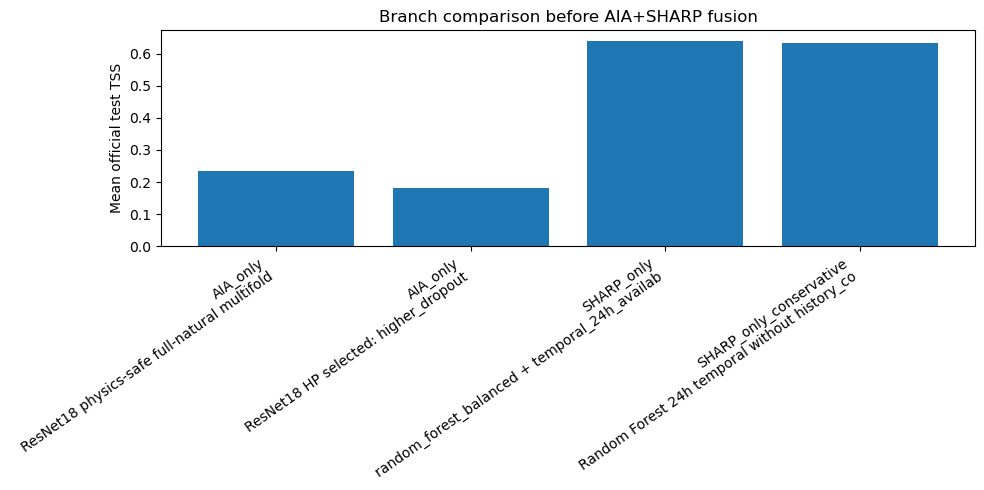

Saved: /Users/mac/Projects/solar-flare-aia-training/results/figures/aia_sharp_fusion_protocol_branch_mean_test_tss.png


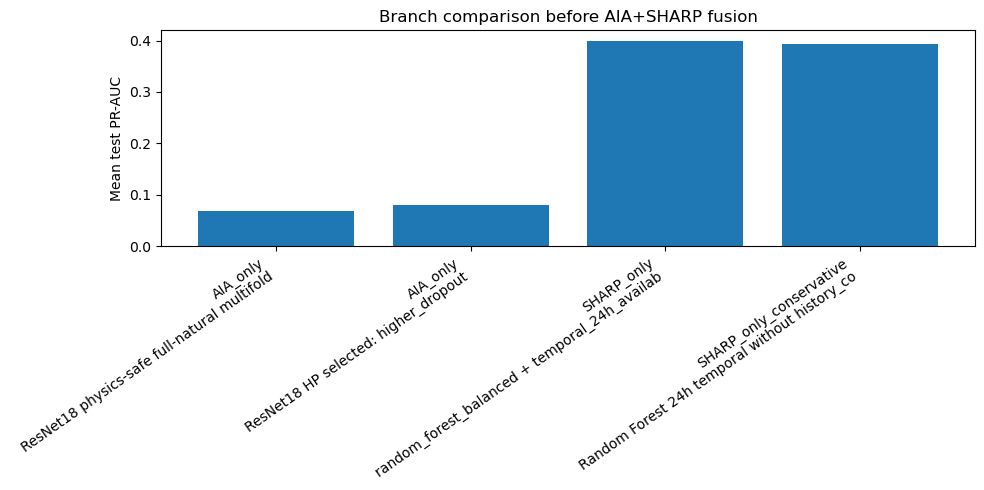

Saved: /Users/mac/Projects/solar-flare-aia-training/results/figures/aia_sharp_fusion_protocol_branch_mean_test_pr_auc.png


In [7]:
import matplotlib.pyplot as plt

plot_df = branch_comparison.dropna(subset=["mean_test_tss"]).copy()
plot_df["label"] = plot_df["branch"] + "\n" + plot_df["candidate_name"].str.slice(0, 45)

if len(plot_df):
    fig = plt.figure(figsize=(10, 5))
    plt.bar(plot_df["label"], plot_df["mean_test_tss"])
    plt.title("Branch comparison before AIA+SHARP fusion")
    plt.ylabel("Mean official test TSS")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    path = FIG_DIR / "aia_sharp_fusion_protocol_branch_mean_test_tss.png"
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

    fig = plt.figure(figsize=(10, 5))
    plt.bar(plot_df["label"], plot_df["mean_test_pr_auc"])
    plt.title("Branch comparison before AIA+SHARP fusion")
    plt.ylabel("Mean test PR-AUC")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    path = FIG_DIR / "aia_sharp_fusion_protocol_branch_mean_test_pr_auc.png"
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)
else:
    print("No branch comparison rows available for plotting.")


## 7. GPU Notebook 16B training plan

In [8]:
gpu_plan = f"""
# 16B GPU Training Plan — AIA + SHARP Intermediate Fusion

**Generated:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

## Objective

Train the first AIA + SHARP intermediate-fusion model using Solar Cycle 24 chronological folds.

This is not a Cycle 24 → Cycle 25 experiment.  
It is a within-cycle chronological/regime robustness experiment across 2010–2015.

## Inputs required on GPU VM

Repository:

`/home/abmoses2000/solar_flare_aia`

Required committed files:

- `training/fusion_manifests/aia_sharp_goes_fusion_alignment_manifest_2010_2016.csv`
- `training/fusion_manifests/aia_sharp_goes_fusion_fold_assignments_2013_2015.csv`
- `results/metrics/aia_sharp_fusion_protocol_candidate_selection.json`
- `results/metrics/aia_sharp_fusion_protocol_fold_readiness.csv`

Required AIA image cache:

- AIA `.npz` files referenced by `gcp_path`
- local cache path should follow the previous image-baseline cache convention

## Primary fusion architecture

### AIA branch

- ResNet18 adapted to 6 AIA channels.
- Input image size: 224×224 or the previous physics-safe image size.
- Preprocessing: train-only robust channel statistics.
- No random flips/rotations/crops.

### SHARP branch

- 24h temporal aggregate vector using available preferred SHARP features.
- Exclude `sharp_24h_history_count` in the primary fusion run.
- Use train-only imputation and scaling per fold.
- Include a sensitivity run with history_count only if clearly labelled.

### Fusion head

- Concatenate AIA embedding + SHARP embedding.
- Dense layers with dropout.
- Binary output logit.
- Loss: BCEWithLogitsLoss with train-fold class imbalance handling.
- Optimiser: AdamW.
- Threshold: selected by validation TSS only.

## Fold protocol

- `test_2013`: train 2010–2011, val 2012, test 2013
- `test_2014`: train 2010–2012, val 2013, test 2014
- `test_2015`: train 2010–2013, val 2014, test 2015

## Required comparisons

Report side-by-side:

1. AIA-only ResNet18 baseline.
2. SHARP-only temporal baseline.
3. AIA+SHARP fusion.
4. Conservative SHARP-only no-history-count result.
5. Optional fusion sensitivity without/with SHARP history_count if run.

## Safety checks

Before training:

- confirm every sample uses `label_48h_final`;
- confirm no embedded `.npz y` is used;
- confirm SHARP features are computed using only times <= `T_REC_dt`;
- confirm train-only normalisation;
- confirm validation-only threshold selection;
- confirm GOES is not used as input.

## Recommended first GPU run

Start with one fold first:

`test_2015`

Reason:

- it has the strongest existing AIA full-natural result;
- it has mature training data volume;
- it provides a fast sanity check before running all folds.

Then run:

- `test_2013`
- `test_2014`

The 2014 fold remains the critical hard regime.
""".strip()

gpu_plan_path = METRICS_DIR / "aia_sharp_fusion_protocol_16B_gpu_training_plan.md"
gpu_plan_path.write_text(gpu_plan, encoding="utf-8")

print(gpu_plan)
print("\nSaved:", gpu_plan_path)


# 16B GPU Training Plan — AIA + SHARP Intermediate Fusion

**Generated:** 2026-08-03 18:54:04

## Objective

Train the first AIA + SHARP intermediate-fusion model using Solar Cycle 24 chronological folds.

This is not a Cycle 24 → Cycle 25 experiment.  
It is a within-cycle chronological/regime robustness experiment across 2010–2015.

## Inputs required on GPU VM

Repository:

`/home/abmoses2000/solar_flare_aia`

Required committed files:

- `training/fusion_manifests/aia_sharp_goes_fusion_alignment_manifest_2010_2016.csv`
- `training/fusion_manifests/aia_sharp_goes_fusion_fold_assignments_2013_2015.csv`
- `results/metrics/aia_sharp_fusion_protocol_candidate_selection.json`
- `results/metrics/aia_sharp_fusion_protocol_fold_readiness.csv`

Required AIA image cache:

- AIA `.npz` files referenced by `gcp_path`
- local cache path should follow the previous image-baseline cache convention

## Primary fusion architecture

### AIA branch

- ResNet18 adapted to 6 AIA channels.
- Input image s

## 8. Research log update

In [9]:
def fmt(x, nd=4):
    try:
        if pd.isna(x):
            return "NA"
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

aia_row = branch_comparison[branch_comparison["paper_role"].eq("image_branch_baseline")]
sharp_row = branch_comparison[branch_comparison["paper_role"].eq("magnetic_branch_baseline")]
sharp_conservative_row = branch_comparison[branch_comparison["paper_role"].eq("conservative_magnetic_branch_reference")]

aia_text = "AIA-only branch evidence was not found in the expected summary file."
if len(aia_row):
    r = aia_row.iloc[0]
    aia_text = f"AIA-only ResNet18 multifold mean official test TSS={fmt(r['mean_test_tss'])} ± {fmt(r['std_test_tss'])}."

sharp_text = "SHARP-only branch evidence was not found in the expected summary file."
if len(sharp_row):
    r = sharp_row.iloc[0]
    sharp_text = f"SHARP-only selected temporal baseline mean official test TSS={fmt(r['mean_test_tss'])} ± {fmt(r['std_test_tss'])}."

sharp_cons_text = ""
if len(sharp_conservative_row):
    r = sharp_conservative_row.iloc[0]
    sharp_cons_text = f"Conservative SHARP no-history-count reference mean official test TSS={fmt(r['mean_test_tss'])} ± {fmt(r['std_test_tss'])}."

log_text = f"""
# Research Log Update — AIA + SHARP Fusion Protocol

**Generated:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

## Current stage

Completed local CPU-only protocol notebook 16A for the first AIA+SHARP fusion experiment.

## Scientific framing

The current dataset and planned fusion folds remain **Solar Cycle 24 only**. The correct interpretation is within-cycle chronological/regime robustness, not Cycle 24 to Cycle 25 generalisation.

## Existing branch evidence

{aia_text}

{sharp_text}

{sharp_cons_text}

## Fusion decision

The first fusion model will use:

- AIA ResNet18 image embedding as the coronal morphology branch.
- SHARP 24h temporal aggregate feature vector as the magnetic evolution branch.
- GOES only as target-label lineage through `label_48h_final`; no GOES/XRS input features yet.

The primary fusion run should exclude `sharp_24h_history_count`; a sensitivity run may include it, but the conservative branch is preferred for paper-safe reporting.

## Rationale

AIA-only modelling showed useful but unstable image-branch skill across chronological regimes. SHARP-only temporal modelling showed substantially stronger magnetic-branch skill after leakage and robustness audit. Fusion is therefore scientifically justified as intermediate fusion between coronal EUV morphology and magnetic evolution.

## Next step

Create and run GPU notebook 16B:

`16B_aia_sharp_intermediate_fusion_training.ipynb`

Start with the `test_2015` fold as a sanity run, then run `test_2013` and `test_2014`.
""".strip()

log_path = METRICS_DIR / "aia_sharp_fusion_protocol_research_log_update.md"
protocol_path = METRICS_DIR / "aia_sharp_fusion_protocol.md"

log_path.write_text(log_text, encoding="utf-8")
protocol_path.write_text(log_text + "\n\n---\n\n" + gpu_plan, encoding="utf-8")

print(log_text)
print("\nSaved:", log_path)
print("Saved:", protocol_path)


# Research Log Update — AIA + SHARP Fusion Protocol

**Generated:** 2026-08-03 18:54:04

## Current stage

Completed local CPU-only protocol notebook 16A for the first AIA+SHARP fusion experiment.

## Scientific framing

The current dataset and planned fusion folds remain **Solar Cycle 24 only**. The correct interpretation is within-cycle chronological/regime robustness, not Cycle 24 to Cycle 25 generalisation.

## Existing branch evidence

AIA-only ResNet18 multifold mean official test TSS=0.2339 ± 0.2227.

SHARP-only selected temporal baseline mean official test TSS=0.6402 ± 0.1902.

Conservative SHARP no-history-count reference mean official test TSS=0.6330 ± 0.2052.

## Fusion decision

The first fusion model will use:

- AIA ResNet18 image embedding as the coronal morphology branch.
- SHARP 24h temporal aggregate feature vector as the magnetic evolution branch.
- GOES only as target-label lineage through `label_48h_final`; no GOES/XRS input features yet.

The primary fusion run sh

## 9. Final inventory

In [10]:
print("Generated protocol metrics/files:")
for p in sorted(METRICS_DIR.glob("aia_sharp_fusion_protocol*")):
    print(" -", p.relative_to(ROOT), f"({p.stat().st_size/1024:.1f} KiB)")

print("\nGenerated figures:")
for p in sorted(FIG_DIR.glob("aia_sharp_fusion_protocol_*.png")):
    print(" -", p.relative_to(ROOT), f"({p.stat().st_size/1024:.1f} KiB)")

print("\nFinished:", datetime.now().isoformat(timespec="seconds"))


Generated protocol metrics/files:
 - results/metrics/aia_sharp_fusion_protocol.md (4.3 KiB)
 - results/metrics/aia_sharp_fusion_protocol_16B_gpu_training_plan.md (2.7 KiB)
 - results/metrics/aia_sharp_fusion_protocol_branch_comparison.csv (1.3 KiB)
 - results/metrics/aia_sharp_fusion_protocol_candidate_selection.csv (0.5 KiB)
 - results/metrics/aia_sharp_fusion_protocol_candidate_selection.json (1.8 KiB)
 - results/metrics/aia_sharp_fusion_protocol_fold_readiness.csv (0.8 KiB)
 - results/metrics/aia_sharp_fusion_protocol_research_log_update.md (1.6 KiB)
 - results/metrics/aia_sharp_fusion_protocol_source_inventory.csv (1.4 KiB)

Generated figures:
 - results/figures/aia_sharp_fusion_protocol_branch_mean_test_pr_auc.png (147.0 KiB)
 - results/figures/aia_sharp_fusion_protocol_branch_mean_test_tss.png (150.6 KiB)

Finished: 2026-08-03T18:54:04
